Il Clustering K-Means è un altro popolare algoritmo di apprendimento non supervisionato utilizzato per trovare gruppi o cluster in un dataset.

2.1 Come Funziona K-Means? 🎯
L'algoritmo K-Means funziona come segue:

Si sceglie un numero k di cluster desiderati.

Si inizializzano k "centroidi" (punti centrali) in modo casuale nello spazio dei dati.

Assegnazione: Ogni punto dati viene assegnato al centroide più vicino.

Aggiornamento: I centroidi vengono ricalcolati come la media di tutti i punti assegnati a quel cluster.

Iterazione: I passaggi 3 e 4 vengono ripetuti finché i centroidi non si muovono più significativamente o viene raggiunto un numero massimo di iterazioni.

In [4]:
#Si carica il dataset Mall_Customers.csv e si 
#selezionano le colonne pertinenti.
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler # Utile per normalizzare i dati

# Carica il dataset (assicurati che il file Mall_Customers.csv sia nella stessa directory o specifichi il percorso corretto)
df_mall = pd.read_csv("Mall_Customers.csv")

# Seleziona le features 'Annual Income (k$)' e 'Spending Score (1-100)'
X_mall = df_mall.iloc[:, [3, 4]].values # Colonna 3 (indice 2) e Colonna 4 (indice 3)
# Nota: nel notebook originale l'iloc è su [3,4], che sono le colonne 4 e 5 di un dataset 0-indexed.
# Assicurati che gli indici corrispondano alle colonne 'Annual Income (k$)' e 'Spending Score (1-100)' nel tuo CSV.

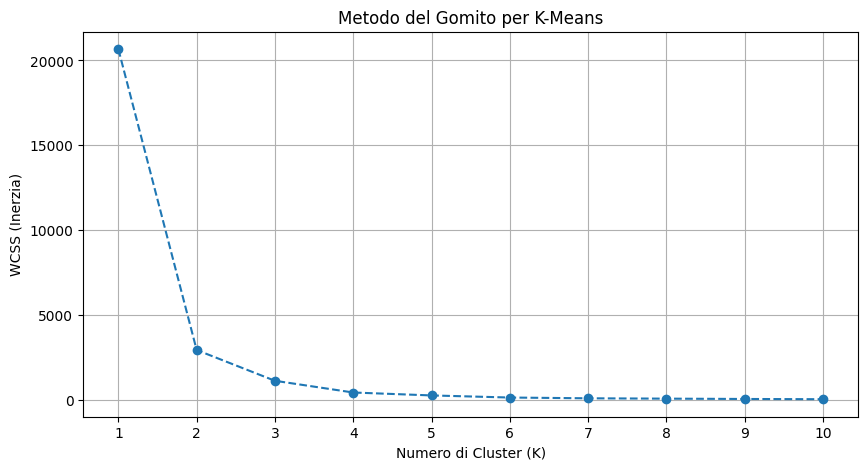

In [5]:
#Il metodo del gomito aiuta a trovare il valore ottimale 
#di k (numero di cluster) per K-Means. Si calcola l'inerzia 
#per diversi valori di k e si cerca il punto in cui la 
#diminuzione dell'inerzia inizia a rallentare, formando 
#una specie di "gomito" sul grafico.
wcss = [] # Sum of squared distances of samples to their closest cluster center (inertia)
for i in range(1, 11): # Prova da 1 a 10 cluster
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10) # n_init=10 per K-Means standard
    kmeans.fit(X_mall)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Metodo del Gomito per K-Means')
plt.xlabel('Numero di Cluster (K)')
plt.ylabel('WCSS (Inerzia)')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

In [6]:
#Una volta scelto il numero ottimale di cluster 
#(ad esempio, n_clusters=5 basandosi sul gomito 
# tipico per questo dataset), si addestra il 
#modello K-Means.
# Esegue il K-Means con il numero ottimale di cluster (es. 5)
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42, n_init=10)
y_kmeans = kmeans.fit_predict(X_mall)

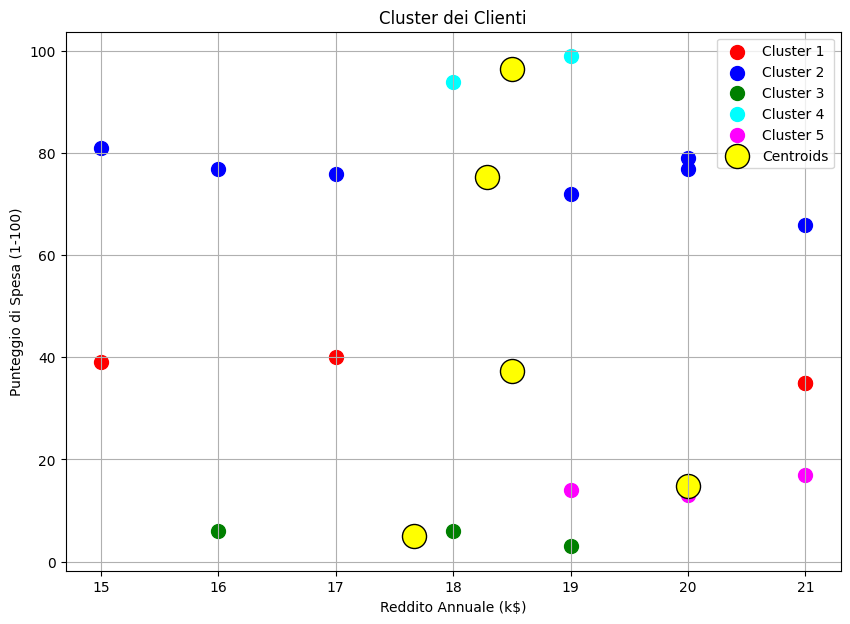

In [7]:
#Si visualizzano i cluster risultanti e i 
#loro centroidi sul grafico a dispersione.
plt.figure(figsize=(10, 7))
plt.scatter(X_mall[y_kmeans == 0, 0], X_mall[y_kmeans == 0, 1], s = 100, c = 'red', label = 'Cluster 1')
plt.scatter(X_mall[y_kmeans == 1, 0], X_mall[y_kmeans == 1, 1], s = 100, c = 'blue', label = 'Cluster 2')
plt.scatter(X_mall[y_kmeans == 2, 0], X_mall[y_kmeans == 2, 1], s = 100, c = 'green', label = 'Cluster 3')
plt.scatter(X_mall[y_kmeans == 3, 0], X_mall[y_kmeans == 3, 1], s = 100, c = 'cyan', label = 'Cluster 4')
plt.scatter(X_mall[y_kmeans == 4, 0], X_mall[y_kmeans == 4, 1], s = 100, c = 'magenta', label = 'Cluster 5')

plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s = 300, c = 'yellow', label = 'Centroids', edgecolors='black')
plt.title('Cluster dei Clienti')
plt.xlabel('Reddito Annuale (k$)')
plt.ylabel('Punteggio di Spesa (1-100)')
plt.legend()
plt.grid(True)
plt.show()